# Are Bayesian Audits Risk-Limiting?

In the below profile, an adversary strategically manipulates 59 / 2997 $\approx$ 2% of the paper ballots.

In the paper ballot profile BAL, the winners are A and B.

In the digital record profile CVR, the winners are A and C.

There just 5 candidates, so the number of possible ballots (326) is still small enough that the Bayesian audit method is viable.

In [5]:
from votekit import RankBallot, RankProfile
from votekit.elections import FastSTV

CVR = RankProfile(
    ballots=tuple(
        [
            RankBallot(ranking=tuple(map(frozenset, ["A", "B"])), weight=800),
            RankBallot(ranking=tuple(map(frozenset, ["B"])), weight=600),
            RankBallot(ranking=tuple(map(frozenset, ["C"])), weight=800),
            RankBallot(ranking=tuple(map(frozenset, ["D", "A"])), weight=258),
            RankBallot(ranking=tuple(map(frozenset, ["E", "A"])), weight=539),
        ]
    ),
    max_ranking_length=2,
)

BAL = RankProfile(
    ballots=tuple(
        [
            RankBallot(ranking=tuple(map(frozenset, ["A", "B"])), weight=800),
            RankBallot(ranking=tuple(map(frozenset, ["B"])), weight=600),
            RankBallot(ranking=tuple(map(frozenset, ["C"])), weight=800),
            RankBallot(ranking=tuple(map(frozenset, ["D", "A"])), weight=199),
            RankBallot(ranking=tuple(map(frozenset, ["E", "A"])), weight=598),
        ]
    ),
    max_ranking_length=2,
)

print("CVR winners:", FastSTV(CVR, n_seats=2).get_elected())
print("BAL winners:", FastSTV(BAL, n_seats=2).get_elected())

CVR winners: (frozenset({'A'}), frozenset({'C'}))
BAL winners: (frozenset({'A'}), frozenset({'B'}))


# Profile Conversion:

We have three datatypes to represent the same object--
1. The richest is a *Votekit Profile*. This is a native Votekit format which can be used to run elections directly. You can think of these as a list of Ballot objects, or as a pandas dataframe.
2. The intermediary is a *numpy ballot matrix*. Each row of this matrix represents a ballot, where candidates are represented by positive integers, and negative integers represent an empty position. These are the easiest to work with and modify directly. Votekit's elections internally turn profiles into these numpy arrays when it is running election logic.
3. The flattest datatype is a *t-type array*. This is just an array of integers: each integer represents a unique permutation of M numbers with length $L\leq M$. These t-types are the ones that Rivest works with in his description of Bayesian RLAs.

Here's some machinery to convert back and forth between these datatypes -- let's how our ballots look in each case.

In [8]:
from src.conversion import profile_to_numpy_ballot_matrix, numpy_ballot_matrix_to_t_type, t_type_to_numpy_ballot_matrix, numpy_ballot_matrix_to_profile

each_ballot_only_once = RankProfile(
    ballots=tuple(
        [
            RankBallot(ranking=tuple(map(frozenset, ["A", "B"])), weight=1),
            RankBallot(ranking=tuple(map(frozenset, ["B"])), weight=1),
            RankBallot(ranking=tuple(map(frozenset, ["C"])), weight=1),
            RankBallot(ranking=tuple(map(frozenset, ["D", "A"])), weight=1),
            RankBallot(ranking=tuple(map(frozenset, ["E", "A"])), weight=1),
        ]
    ),
    max_ranking_length=2,
)

print("Votekit ballot matrix:")
print(each_ballot_only_once.df)
ballot_matrix = profile_to_numpy_ballot_matrix(each_ballot_only_once)
print("Numpy ballot matrix:")
print(ballot_matrix)
t_type = numpy_ballot_matrix_to_t_type(ballot_matrix, m=5, L=4)
print("T-type vector:")
print(t_type)

Votekit ballot matrix:
                   Ranking_1       Ranking_2 Voter Set  Weight
Ballot Index                                                  
0             frozenset({A})  frozenset({B})        {}     1.0
1             frozenset({B})  frozenset({~})        {}     1.0
2             frozenset({C})  frozenset({~})        {}     1.0
3             frozenset({D})  frozenset({A})        {}     1.0
4             frozenset({E})  frozenset({A})        {}     1.0
Numpy ballot matrix:
[[   0    1 -127]
 [   1 -127 -127]
 [   2 -127 -127]
 [   3    0 -127]
 [   4    0 -127]]
T-type vector:
[  2  42  83 125 166]


In [9]:
# turn BAL and CVR into t-type vectors
ballot_matrix_BAL = profile_to_numpy_ballot_matrix(BAL)
t_type_BAL = numpy_ballot_matrix_to_t_type(ballot_matrix_BAL, m=5, L=4)

ballot_matrix_CVR = profile_to_numpy_ballot_matrix(CVR)
t_type_CVR = numpy_ballot_matrix_to_t_type(ballot_matrix_CVR, m=5, L=4)

# shuffle them together
import numpy as np
zipped = list(zip(t_type_BAL, t_type_CVR))
np.random.shuffle(zipped)
t_type_BAL_shuffled, t_type_CVR_shuffled = zip(*zipped)

print("first 20 of each:")
print("BAL:", np.array(t_type_BAL_shuffled[:20]).astype(int))
print("CVR:", np.array(t_type_CVR_shuffled[:20]).astype(int))

first 20 of each:
BAL: [ 83  42 125   2  83 166 166 166  42  83  42 166 125  42  42 166   2 125
  83   2]
CVR: [ 83  42 125   2  83 166 166 166  42  83  42 166 125  42  42 166   2 125
  83   2]


Let's also make a noised version of the CVR t-type vector, which we can use to model a non-adversarial BAL

In [10]:
# pick 59 positions randomly in 0, 1, ..., len(t_type_CVR_shuffled)-1
noisy_t_type_CVR_shuffled = np.copy(t_type_CVR_shuffled)
random_indices = np.random.choice(len(t_type_CVR_shuffled), size=59, replace=False)
possible_t_types = [2, 42, 83, 125, 166]
for idx in random_indices:
    # replace it with a random *different* t-type from the possible t-types
    current_t_type_CVR = t_type_CVR_shuffled[idx]
    possible_replacements = [t for t in possible_t_types if t != current_t_type_CVR]
    noisy_t_type_CVR_shuffled[idx] = np.random.choice(possible_replacements)

print("first 20 of each:")
print("BAL:", np.array(t_type_BAL_shuffled[:20]).astype(int))
print("CVR:", np.array(t_type_CVR_shuffled[:20]).astype(int))
print("Noisy CVR:", np.array(noisy_t_type_CVR_shuffled[:20]).astype(int)) 

noised_matrix = t_type_to_numpy_ballot_matrix(noisy_t_type_CVR_shuffled, m=5, L=4)
print("noised matrix:", noised_matrix)
noised_profile = numpy_ballot_matrix_to_profile(noised_matrix, M=5)
print("Outcome under Noisy CVR:", FastSTV(noised_profile, n_seats=2).get_elected())
print("Outcome under CVR:", FastSTV(CVR, n_seats=2).get_elected())

first 20 of each:
BAL: [ 83  42 125   2  83 166 166 166  42  83  42 166 125  42  42 166   2 125
  83   2]
CVR: [ 83  42 125   2  83 166 166 166  42  83  42 166 125  42  42 166   2 125
  83   2]
Noisy CVR: [ 83  42 125   2  83 166 166 166  42  83  42 166 125  42  42 166   2 125
  83   2]
noised matrix: [[ 2 -1 -1 -1]
 [ 1 -1 -1 -1]
 [ 3  0 -1 -1]
 ...
 [ 4  0 -1 -1]
 [ 4  0 -1 -1]
 [ 4  0 -1 -1]]
Outcome under Noisy CVR: (frozenset({'A'}), frozenset({'C'}))
Outcome under CVR: (frozenset({'A'}), frozenset({'C'}))


To check that the CVR profile we built would be auditable under normal conditions, a reasonable thing to try is just to randomly generate many such noisy CVRs, and see how often the outcome is the same.

In [10]:
from tqdm import tqdm


upsets = 0
for _ in tqdm(range(1000)):
    temp_noisy_t_type_CVR_shuffled = np.copy(t_type_CVR_shuffled)
    random_indices = np.random.choice(len(t_type_CVR_shuffled), size=59, replace=False)
    for idx in random_indices:
        # replace it with a random *different* t-type from the possible t-types
        current_t_type_CVR = t_type_CVR_shuffled[idx]
        possible_replacements = [t for t in possible_t_types if t != current_t_type_CVR]
        temp_noisy_t_type_CVR_shuffled[idx] = np.random.choice(possible_replacements)
        temp_profile = numpy_ballot_matrix_to_profile(t_type_to_numpy_ballot_matrix(temp_noisy_t_type_CVR_shuffled, m=5, L=4), M=5)
    if FastSTV(temp_profile, n_seats=2).get_elected() !=(frozenset({'A'}), frozenset({'C'})):
        upsets += 1
print("Upset probability:", upsets / 5000)

100%|██████████| 1000/1000 [08:59<00:00,  1.85it/s]

Upset probability: 0.0


# Naive Haldane Prior

Rivest isn't explicit about how to initialize the matrix of prior parameters C. Clearly, we expect more weight on the diagonals than the off-diagonals.

One naive option is to initialize that matrix with 0s only, and only start sampling posteriors once every row has been sampled. This is a pretty bad idea, even in our over-simplified toy example: it's saying that if a discrepancy type (i, j) never appears in our data, the posterior will never give any weight to that discrepancy either. In particular, if our data hasn't seen a discrepancy yet in a given row, the posterior for that row will look deterministically like the CVR. If we've never sampled a discrepancy at all, the posterior will be supported only on the CVR, and we will always auto-certify the election. 

This is a bad idea.

In [52]:
import tqdm

uniq, CVR_counts = np.unique(t_type_CVR, return_counts=True)
lut = np.zeros(uniq.max() + 1, dtype=int) -1
lut[uniq] = np.arange(len(uniq))
prior_mat = np.zeros((len(uniq), len(lut)), dtype=int)

seed = 5
rng = np.random.default_rng(seed)

batch_size = 10
first_time = True
upset_probs = []
num_discrepancies = 0
discrepancies = []

number_of_samples_per_posterior = 1000

for i in range(0, 100):
    batch_BAL = t_type_BAL_shuffled[i*batch_size : (i+1)*batch_size]
    batch_CVR = t_type_CVR_shuffled[i*batch_size : (i+1)*batch_size]
    num_discrepancies += batch_size - np.sum(np.equal(batch_BAL, batch_CVR))
    discrepancies.append(int(num_discrepancies))

    for t_BAL, t_CVR in zip(batch_BAL, batch_CVR):
        prior_mat[lut[t_CVR], t_BAL] += 1

    row_wise_sums = prior_mat.sum(axis=1) 

    if np.all(row_wise_sums > 0) and first_time:
        print(f"Each CVR t-type has been observed at least once after batch {i}.")
        first_time = False
    
    if first_time:
        upset_probs.append(1.0)
    else:
        unobserved_CVR_per_type = CVR_counts - row_wise_sums
        upsets = 0
        for j in tqdm.tqdm(range(number_of_samples_per_posterior)):
            list_of_dirichlet_samples = [
                rng.dirichlet(prior_mat[k]) for k in range(prior_mat.shape[0])
            ]
            sample = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples[k] for k in range(prior_mat.shape[0])])
            t_type_weights = np.sum(sample + prior_mat, axis=0)
            uniq_t_types = np.nonzero(t_type_weights)[0]
            numpy_profile = t_type_to_numpy_ballot_matrix(uniq_t_types, m=5, L=5)
            votekit_profile = numpy_ballot_matrix_to_profile(numpy_profile, M=5, wt_vec=t_type_weights[uniq_t_types])
            winners = FastSTV(votekit_profile, n_seats=2).get_elected()
            if winners != (frozenset({'A'}), frozenset({'C'})):
                upsets += 1
        upset_probs.append(upsets / number_of_samples_per_posterior)


Each CVR t-type has been observed at least once after batch 2.


 38%|███▊      | 385/1000 [00:00<00:01, 415.77it/s]


KeyboardInterrupt: 

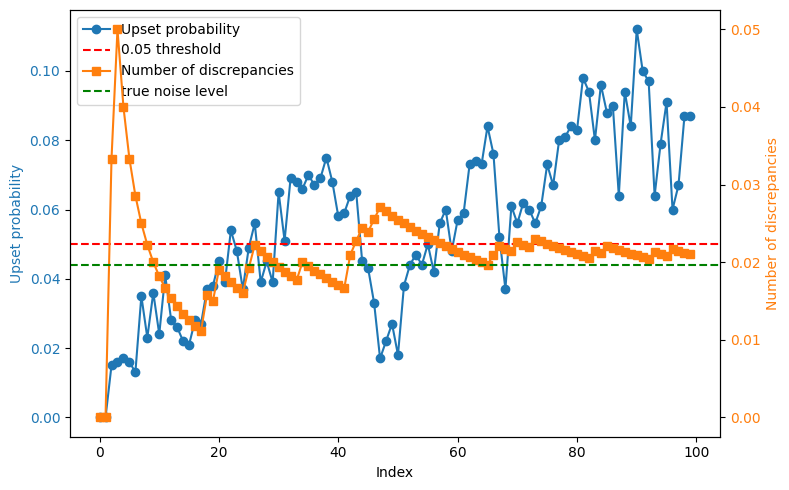

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upset_probs))

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upset_probs, color="tab:blue", marker="o", label="Upset probability")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(59/2997, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Index")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

A more logical thing to do is to initialize each row with small non-zero weights on the off-diagonals. Here's how I operationalized this:

We set a prior strength $\kappa$ and an expected noise level $\eta$ for the audit. We give the diagonal entry of each row $\kappa * (1-\eta)$, and we distribute the remaining weight $\kappa*\eta$ evenly among the remaining $T$ entries of the row.

Deciding how to tune $\kappa$ is not obvious. We want it to be weak enough so that without any data, the probability of an upset is high enough that we don't always certify the election. We can tune this with our noised CVR, by tweaking $\kappa$ until we are satisfied with the timing of our first certification. Aiming for 50-150 ballots seems reasonable.

In [ ]:
import tqdm

T = 206
# you can switch around kappa values here
kappa_1 = 1/10
kappa_2 = 1
kappa_3 = 10
eta = 59/3997

# the below is for a low-noise prior
epsilon_1 = eta*kappa_1/(T-1)
epsilon_2 = eta*kappa_2/(T-1)
epsilon_3 = eta*kappa_3/(T-1)

# the below is for a pessimistic prior
#epsilon_1 = kappa_1/(T-1)
#epsilon_2 = kappa_2/(T-1)
#epsilon_3 = kappa_3/(T-1)

# the below is for a uniform prior 
#epsilon_1 = kappa_1/T
#epsilon_2 = kappa_2/T
#epsilon_3 = kappa_3/T

uniq, CVR_counts = np.unique(t_type_CVR, return_counts=True)
lut = np.zeros(uniq.max() + 1, dtype=int) -1
lut[uniq] = np.arange(len(uniq))
prior_mat_1 = np.zeros((len(uniq), T), dtype=float)
prior_mat_2 = np.zeros((len(uniq), T), dtype=float)
prior_mat_3 = np.zeros((len(uniq), T), dtype=float)
D_mat = np.zeros((len(uniq), T), dtype=float)
prior_mat_1 += epsilon_1
prior_mat_2 += epsilon_2
prior_mat_3 += epsilon_3

# the below is for a low-noise prior
for t in uniq:
    prior_mat_1[lut[t],t] = kappa_1*(1-eta)
    prior_mat_2[lut[t],t] = kappa_2*(1-eta)
    prior_mat_3[lut[t],t] = kappa_3*(1-eta)

# the below is for a pessimistic prior
#for t in uniq:
#    prior_mat_1[lut[t],t] = 0
#    prior_mat_2[lut[t],t] = 0
#    prior_mat_3[lut[t],t] = 0

seed = 5
rng = np.random.default_rng(seed)

batch_size = 10
first_time = True
upset_probs_1 = []
upset_probs_2 = []
upset_probs_3 = []
num_discrepancies = 0
discrepancies = []

number_of_samples_per_posterior = 1000

for i in range(0, 100):
    #batch_noise_CVR = noisy_t_type_CVR_shuffled[i*batch_size : (i+1)*batch_size]
    batch_noise_CVR = t_type_BAL_shuffled[i*batch_size : (i+1)*batch_size]
    batch_CVR = t_type_CVR_shuffled[i*batch_size : (i+1)*batch_size]
    num_discrepancies += batch_size - np.sum(np.equal(batch_noise_CVR, batch_CVR))
    discrepancies.append(int(num_discrepancies)/(batch_size*(i+1)))

    for t_BAL, t_CVR in zip(batch_noise_CVR, batch_CVR):
        D_mat[lut[t_CVR], t_BAL] += 1

    row_wise_mass = D_mat.sum(axis=1)
    
    unobserved_CVR_per_type = CVR_counts - row_wise_mass
    upsets_1 = 0
    upsets_2 = 0
    upsets_3 = 0
    for j in tqdm.tqdm(range(number_of_samples_per_posterior)):
        list_of_dirichlet_samples_1 = [
            rng.dirichlet(prior_mat_1[k] + D_mat[k]) for k in range(prior_mat_1.shape[0])
        ]
        list_of_dirichlet_samples_2 = [
            rng.dirichlet(prior_mat_2[k] + D_mat[k]) for k in range(prior_mat_2.shape[0])
        ]
        list_of_dirichlet_samples_3 = [
            rng.dirichlet(prior_mat_3[k] + D_mat[k]) for k in range(prior_mat_3.shape[0])
        ]
        sample_matrix_1 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_1[k] for k in range(prior_mat_1.shape[0])])
        sample_matrix_2 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_2[k] for k in range(prior_mat_2.shape[0])])
        sample_matrix_3 = np.stack([unobserved_CVR_per_type[k] * list_of_dirichlet_samples_3[k] for k in range(prior_mat_3.shape[0])])
        t_type_weights_1 = np.sum(sample_matrix_1 + D_mat, axis=0)
        t_type_weights_2 = np.sum(sample_matrix_2 + D_mat, axis=0)
        t_type_weights_3 = np.sum(sample_matrix_3 + D_mat, axis=0)
        uniq_t_types_1 = np.nonzero(t_type_weights_1)[0]
        uniq_t_types_2 = np.nonzero(t_type_weights_2)[0]
        uniq_t_types_3 = np.nonzero(t_type_weights_3)[0]
        numpy_profile_1 = t_type_to_numpy_ballot_matrix(uniq_t_types_1, m=5, L=4)
        numpy_profile_2 = t_type_to_numpy_ballot_matrix(uniq_t_types_2, m=5, L=4)
        numpy_profile_3 = t_type_to_numpy_ballot_matrix(uniq_t_types_3, m=5, L=4)
        votekit_profile_1 = numpy_ballot_matrix_to_profile(numpy_profile_1, M=5, wt_vec=t_type_weights_1[uniq_t_types_1])
        votekit_profile_2 = numpy_ballot_matrix_to_profile(numpy_profile_2, M=5, wt_vec=t_type_weights_2[uniq_t_types_2])
        votekit_profile_3 = numpy_ballot_matrix_to_profile(numpy_profile_3, M=5, wt_vec=t_type_weights_3[uniq_t_types_3])
        winners_1 = FastSTV(votekit_profile_1, n_seats=2).get_elected()
        winners_2 = FastSTV(votekit_profile_2, n_seats=2).get_elected()
        winners_3 = FastSTV(votekit_profile_3, n_seats=2).get_elected()
        if winners_1 != (frozenset({'A'}), frozenset({'C'})):
            upsets_1 += 1
        if winners_2 != (frozenset({'A'}), frozenset({'C'})):
            upsets_2 += 1
        if winners_3 != (frozenset({'A'}), frozenset({'C'})):
            upsets_3 += 1
    upset_probs_1.append(upsets_1 / number_of_samples_per_posterior)
    upset_probs_2.append(upsets_2 / number_of_samples_per_posterior)
    upset_probs_3.append(upsets_3 / number_of_samples_per_posterior)


100%|██████████| 1000/1000 [00:07<00:00, 135.93it/s]


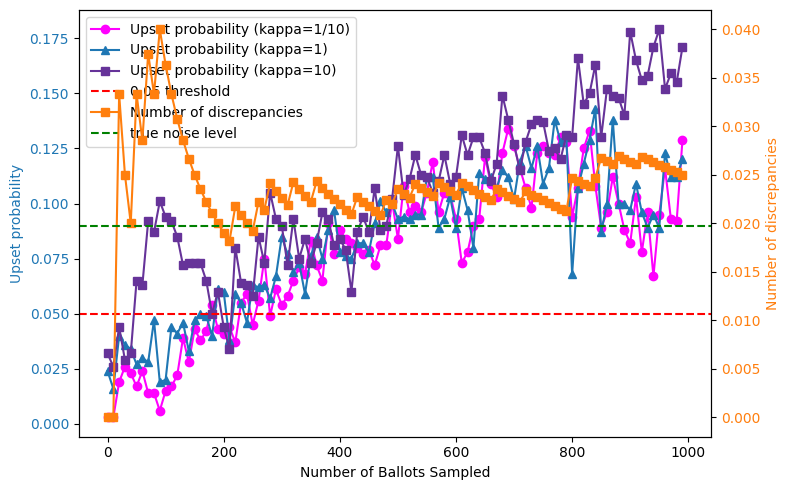

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upset_probs_1)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upset_probs_1, color="magenta", marker="o", label="Upset probability (kappa=1/10)")
ax_left.plot(x, upset_probs_2, color="tab:blue", marker="^", label="Upset probability (kappa=1)")
ax_left.plot(x, upset_probs_3, color="rebeccapurple", marker="s", label="Upset probability (kappa=10)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(59/2997, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

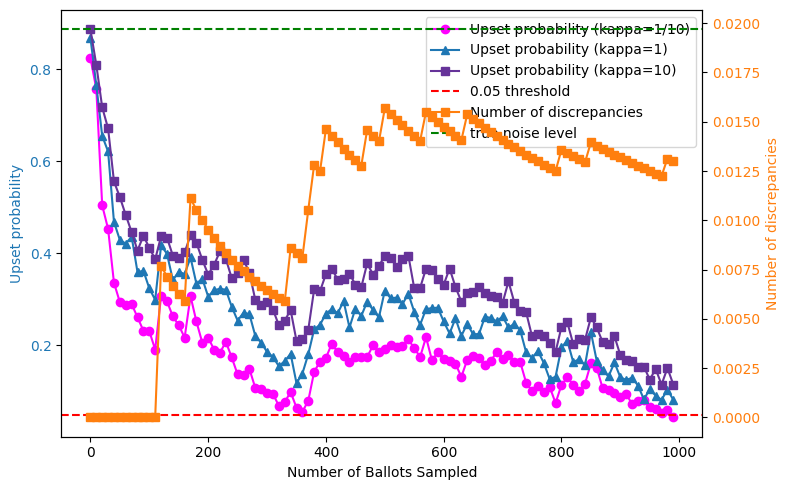

In [42]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(upset_probs_1)*10, step=10)

fig, ax_left = plt.subplots(figsize=(8, 5))
ax_right = ax_left.twinx()

ax_left.plot(x, upset_probs_1, color="magenta", marker="o", label="Upset probability (kappa=1/10)")
ax_left.plot(x, upset_probs_2, color="tab:blue", marker="^", label="Upset probability (kappa=1)")
ax_left.plot(x, upset_probs_3, color="rebeccapurple", marker="s", label="Upset probability (kappa=10)")
ax_right.plot(x, discrepancies, color="tab:orange", marker="s", label="Number of discrepancies")

ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax_right.axhline(59/2997, color="green", linestyle="--", linewidth=1.5, label="true noise level")

ax_left.set_xlabel("Number of Ballots Sampled")
ax_left.set_ylabel("Upset probability", color="tab:blue")
ax_right.set_ylabel("Number of discrepancies", color="tab:orange")

ax_left.tick_params(axis="y", labelcolor="tab:blue")
ax_right.tick_params(axis="y", labelcolor="tab:orange")

lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

plt.tight_layout()
plt.show()

In [36]:
from copy import copy

backup_upset_probs_1 = copy(upset_probs_1)
backup_upset_probs_2 = copy(upset_probs_2)
backup_upset_probs_3 = copy(upset_probs_3)
backup_discrepancies = copy(discrepancies)

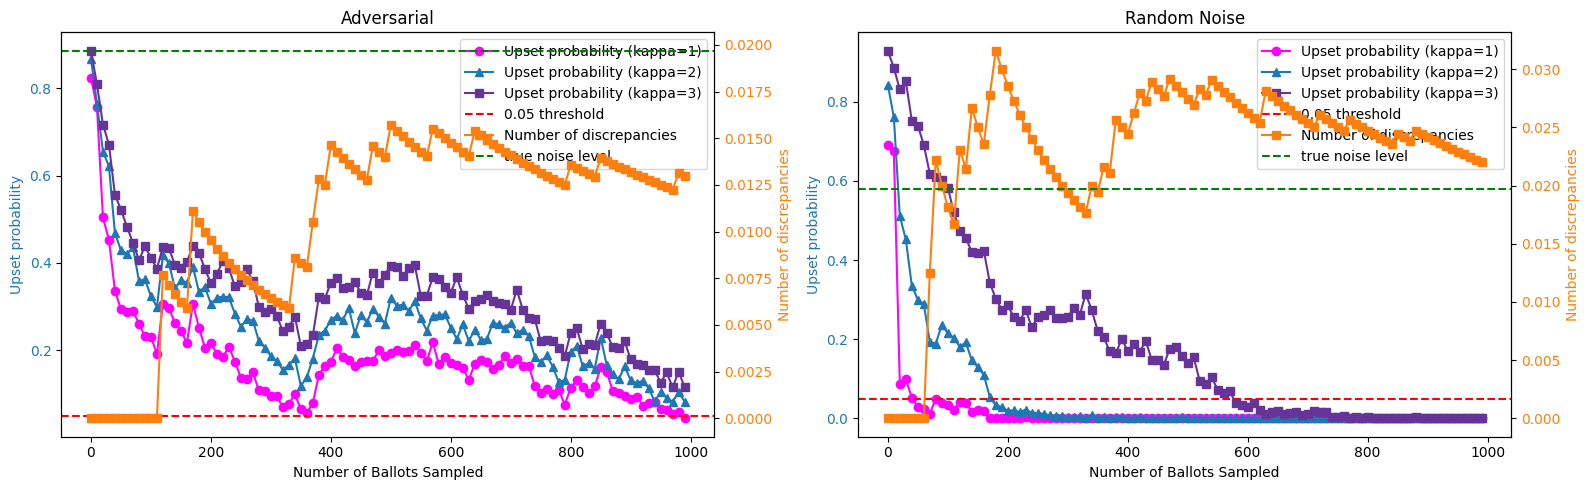

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_panel(ax_left, upset1, upset2, upset3, disc, title):
    x = np.arange(len(upset1) * 10, step=10)
    ax_right = ax_left.twinx()

    ax_left.plot(x, upset1, color="magenta", marker="o", label="Upset probability (kappa=1)")
    ax_left.plot(x, upset2, color="tab:blue", marker="^", label="Upset probability (kappa=2)")
    ax_left.plot(x, upset3, color="rebeccapurple", marker="s", label="Upset probability (kappa=3)")
    ax_right.plot(x, disc, color="tab:orange", marker="s", label="Number of discrepancies")

    ax_left.axhline(0.05, color="red", linestyle="--", linewidth=1.5, label="0.05 threshold")
    ax_right.axhline(59/2997, color="green", linestyle="--", linewidth=1.5, label="true noise level")

    ax_left.set_xlabel("Number of Ballots Sampled")
    ax_left.set_ylabel("Upset probability", color="tab:blue")
    ax_right.set_ylabel("Number of discrepancies", color="tab:orange")
    ax_left.tick_params(axis="y", labelcolor="tab:blue")
    ax_right.tick_params(axis="y", labelcolor="tab:orange")
    ax_left.set_title(title)

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

# Side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_panel(
    axes[0],
    upset_probs_1, upset_probs_2, upset_probs_3,
    discrepancies,
    title="Adversarial"
)

plot_panel(
    axes[1],
    backup_upset_probs_1, backup_upset_probs_2, backup_upset_probs_3,
    backup_discrepancies,  # if you don't have this, use `discrepancies`
    title="Random Noise"
)

plt.tight_layout()
plt.show()
